Neuromorphic engineering I

## Lab 10: Silicon Synaptic Circuits

Team member 1: Kalle Falk

Team member 2: Marius Fauteux

Date: 17/11-2025

----------------------------------------------------------------------------------------------------------------------

This week, we will see how synaptic circuits generate currents when stimulated by voltage pulses. Specifically we will measure the response of the synapse to a single pulse, and to a sequence of spikes.

The objectives of this lab are to:
- Analyze log-domain synapse circuits.
- Measure the response properties of the diff-pair integrator (DPI).

## 1 Reading

The following papers give usefull insight on the subject:

- [**Bartolozzi, Indiveri, 2007**  Synaptic dynamics in analog VLSI](https://doi.org/10.1162/neco.2007.19.10.2581)



## 2 Prelab

<div id="fig:02:wta-schematic"
    style=" border-radius: 5px;
                border: 1px solid rgba(0,0,0,0.1);
                padding: 1em;
    ">

![DPI synapse](figs/DPIsynapse.png)

**Figure 1**: Schematic of a Differential Pair Integrator (DPI) circuit

</div>

All of the following prelab questions refer to the circuit schematic shown in **Figure 1**.

* <font color=#108ee9> Write the equations characterizing
$I_{\rm w}, I_{\rm thr} , I_{\rm in}, I_{\tau}, I_{\rm syn}, I_C$
assuming all corresponding FETs are in saturation and operate in weak-inversion.
</font>

* <font color=#108ee9> What is the time constant of the circuit? </div>

<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">

$$
I_w = I_{thr}+I_{in}= I_0 \cdot \textrm{e}^{\frac{\kappa \cdot V_{thr}-V_s}{U_T}} + I_0 \cdot \textrm{e}^{\frac{\kappa \cdot V_{syn}-V_s}{U_T}}
$$

$$
I_{thr} = I_w - I_{in} = I_0 \cdot \textrm{e}^{\frac{\kappa \cdot V_{thr}-V_s}{U_T}} =   I_0 \cdot \textrm{e}^{\frac{\kappa \cdot V_{W}-V_{M_{pre},s}}{U_T}} - I_0 \cdot \textrm{e}^{\frac{\kappa \cdot V_{syn}-V_s}{U_T}}
$$

$$
I_{in} = I_{\tau}+I_C =  I_0 \cdot \textrm{e}^{\frac{\kappa \cdot V_{syn}-V_s}{U_T}}
$$

$$
I_C = C \cdot \frac{dV_C}{dt} = C \cdot \frac{d(V_{dd}-V_{syn})}{dt}=  C \cdot \frac{d(-V_{syn})}{dt}
$$

$$
I_{syn} = I_0 \cdot \textrm{e}^{\frac{-\kappa \cdot V_{syn}+V_{dd}}{U_T}}
$$
</div>

<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">
Combined we get


$$
\frac{I_w}{I_{\tau}} \cdot \frac{I_{syn}}{1+I_{syn}} = I_{syn}+\frac{C}{\kappa \cdot I_{\tau}} \cdot \frac{dI_{syn}}{dt}
$$

where

$$
\tau = \frac{C}{\kappa \cdot I_{\tau}}
$$

</div>

* <font color=#108ee9> Derive the circuit's response to a step input assuming

</font>

$$
\left\{
\begin{split}
& I_{w}(t < 0) = 0 \\
& I_{w}(t > 0) \gg I_{\tau}
\end{split}
\right.
$$

<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">

When we apply a step function at the input (the gate of $M_{pre}$), then we start to sink current ($I_w$) from the $V_s$ node with a conductance determined by $V_W$. If $I_W \gg I_{\tau}$ then we start to discharge the capacitor through the current $I_{in}$. As we sink current $I_{in}$, $V_{syn}$ also decreases, which inturn increases the current through the $M_{post}$ (notice it is a PFET) i.e I_syn increases.

It does not increase linealry but by $(1-\mathrm{e}^{\frac{-t}{\tau}}$), i.e at a rate determined by the time constant $\tau$. This is because as C discharges and $V_{syn}$ goes down we have a negative feedback as $V_syn$ is also the gate voltage of $M_in$. Thus as $V_syn$ decreases, less current is delivered and the saturates.

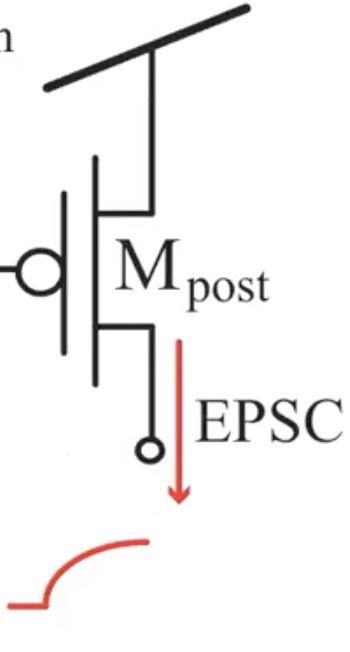


</div>

* <font color=#108ee9> Derive the circuit's response to a step input assuming
</font>

$$
\left\{
\begin{split}
& I_{w}(t < 0) \gg I_{\tau} \\
& I_{w}(t > 0) = 0
\end{split}
\right.
$$


<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">

When we turn of the circuit input step function, then $I_W$ goes to 0 as no current can pass through $M_pre$. Therfore no current passes through $M_in$ and all the $I_{tau}$ current then flows to the capacitor which charges. Hence $V_{syn}$ increases and it being the gate voltage of the $M_{post}$ PFET, the current through the $M_{post}$  ($I_{syn}$)decreases exponentially at a rate of $\mathrm{e}^{\frac{-t}{\tau}}$ (blue part of curve below).

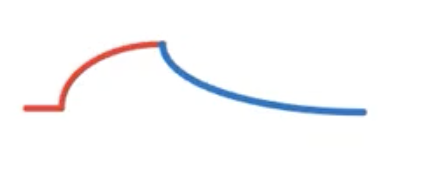
</div>

* Suppose we stimulate the circuit with a regular spike train
of frequency $f$ (high enough). <font color=#108ee9> What happens to $I_{syn}$
in steady-state (average value)? </font>


<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">
the first spike will follow the left side equation, where the first term is non-negilble. The right side equation is satisfied for subsequent spikes where $I_{out}=I_{syn}$ is large enoiugh for the first term of the left side equation to diminish to a negligable size.

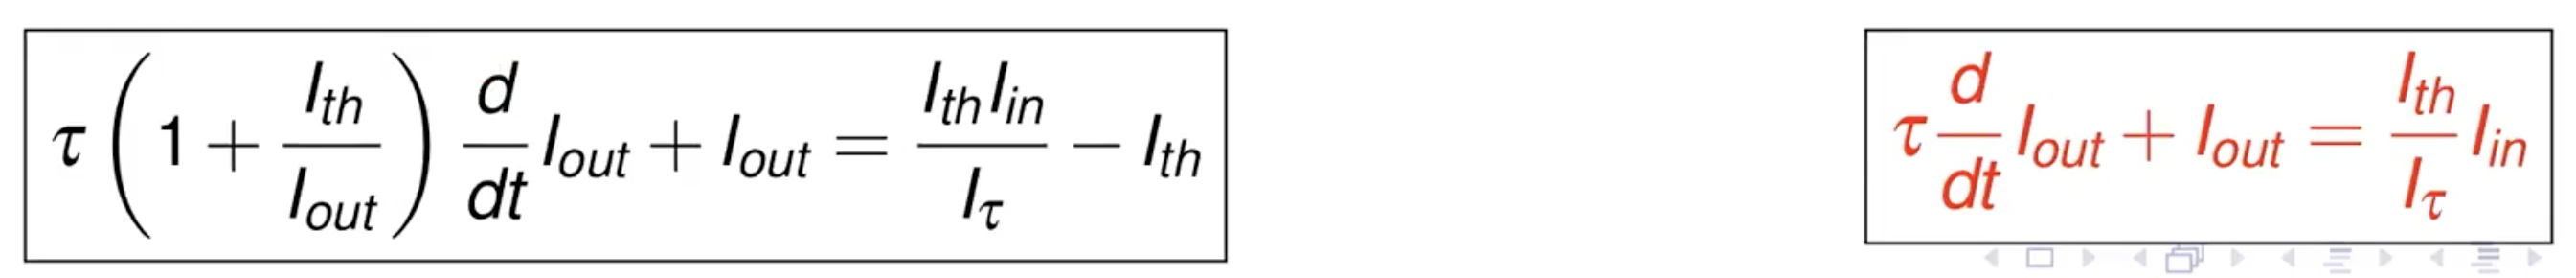


</div>

* <font color=#108ee9> In what conditions (tau and thr) is the step response dependent only on $I_{w}$?
</font>

<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">



</div>

# 3 Setup

Import necessary python libraries. The cell below may be collapsed.

In [4]:
import time # for time.sleep(seconds)
import numpy as np # numpy for arrays etc
from scipy import stats, interpolate # for stats.linregress
import matplotlib
import matplotlib.pyplot as plt # for plotting
import matplotlib
plt.rcParams.update({'font.size': 10}) # make the detault font size larger for your readers
matplotlib.rcParams['pdf.fonttype'] = 42 # save fonts as type that are not outlined in illustrator or other drawing programs
from engineering_notation import EngNumber as ef # format numbers in engineering format quickly, e.g. ef(2e-9)='2n' https://pypi.org/project/engineering-notation/
from pathlib import Path # used for saving data

datapath = Path('data/dpi') # make a data folder to save your data called data/lab5
datapath.mkdir(parents=True, exist_ok=True)
from jupyter_save_load_vars import savevars, loadvars
from tqdm import tqdm

from IPython.display import display, Markdown, Latex, clear_output

import pyplane # for type hinting of biasgen constants
from ne1 import Coach # import Coach() class
import logging
# below lines are notebook magic for debugging, you can uncomment them when debugging the Coach() class
# %load_ext autoreload
# %autoreload explicit
# %aimport ne1

In [5]:
# create a Plane object and open the communication
c=Coach(logging_level=logging.INFO) # NOTE change to INFO to reduce clutter - create a Coach object called p; you will use it to talk to class chip, change to logging.DEBUG for troubleshooting
c.open()

[INFO]: 2025-11-11 15:54:11,242 - NE1 - Opened CoACH at /dev/cu.usbmodem76219301 with firmware version (1, 12, 5) (File "/Users/jesperjorgen/Desktop/pappas_comp/1UNI/ETH/NE1/CoACH-LABS/ne1.py", line 175, in open)


## 3.1 Chip configuration

* To measure DPI synapse:

In [6]:
c.setup_dpi()

## 3.2 C2F

* To set up the C2F circuit:

In [7]:
c.setup_c2f()
# we also need to setup the output rail-to-rail buffer
c.setup_r2r_buffer()
# calibration of the c2f
C2F = c.DPI_C2F(c)

# 4 DPI synapse

The **DPI synapse** receives a voltage pulse train, $V_{pulse}$, as input and
outputs a corresponding synaptic current, $I_{syn}$. Additionally, the synaptic voltage, $V_{syn}$, is provided.
Bias parameters $V_{weight}$ & $V_{tau}$ affect the amplitude and decay of the response, while $V_{thr}$ acts as an additional weight bias. $C_{syn}$ sizing was chosen for a capacitance of 2pF. 

<div id="fig:02:wta-schematic"
    style=" border-radius: 5px;
                border: 1px solid rgba(0,0,0,0.1);
                padding: 1em;
    ">
    
![CoACH DPI synapse circuit](figs/coachDPIsynapse.png)

**Figure 2: Schematic of the DPI circuit present on the CoACH board**

</div>

**$$
\begin{alignedat}{4}
& V_{\rm syn}  && = {\rm DPI\_VSYN\_VO} && = \quad && {\rm ADC[14]}
\\
& I_{\rm syn} && = {\rm DPI\_ISYN1\_UO} && = &&  {\rm C2F[9]}
\end{alignedat}
$$**

The task of this exercise it to tune the parameters and observe the behavior of the DPI synapse.

## 4.1 Basic impulse response

- **Set parameters**

Do you still remember how the bias gen works? 

The DPI is a current mode circuit, so it is useful to think in terms of the biases not simply as the voltages
applied to the gates, but as the current that are being mirrored through the respective devices.

* <font color=#108ee9> What are the resulting currents on the CoACH board set from the cell below? </font>

In [8]:
c.set_bias(
    pyplane.Coach.BiasAddress.DPI_VTAU_P,
    pyplane.Coach.BiasType.P,
    pyplane.Coach.BiasGenMasterCurrent.I60pA,
    25
)

c.set_bias(
    pyplane.Coach.BiasAddress.DPI_VTHR_N,
    pyplane.Coach.BiasType.P,
    pyplane.Coach.BiasGenMasterCurrent.I60pA,
    30
)

c.set_bias(
    pyplane.Coach.BiasAddress.DPI_VWEIGHT_N,
    pyplane.Coach.BiasType.N,
    pyplane.Coach.BiasGenMasterCurrent.I30nA,
    100
)

c.set_bias(
    pyplane.Coach.BiasAddress.PEX_VTAU_N,
    pyplane.Coach.BiasType.N,
    pyplane.Coach.BiasGenMasterCurrent.I60pA,
    10
)

2.3529411764705883e-12

<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">



</div>

- **Data acquisition**

In the data acquisition phase of each section of this lab, we will measure the response of the DPI synapse to two
input pulses, collecting 10 samples per pulse response and recording the output.

In [9]:
N_pulses = 2 # for each trial, send 2 input pulses
N_samples_per_pulse = 15 # for each input pulse, sample 10 points

N_samples = N_pulses*N_samples_per_pulse

dT = 0.02 # delta t between the samples, DO NOT CHANGE

t = np.arange(N_samples)*dT
vsyn = np.zeros(N_samples)
isyn = np.zeros(N_samples)

for k in tqdm(range(N_pulses)):
    c.send_dpi_pulse()
    
    for i in range(N_samples_per_pulse):
        vsyn[k*N_samples_per_pulse+i] += c.measure_dpi_vsyn()
        isyn[k*N_samples_per_pulse+i] += c.measure_c2f_freqs(duration=dT)[9]

100%|██████████| 2/2 [00:00<00:00,  2.54it/s]


- **Plot the data**

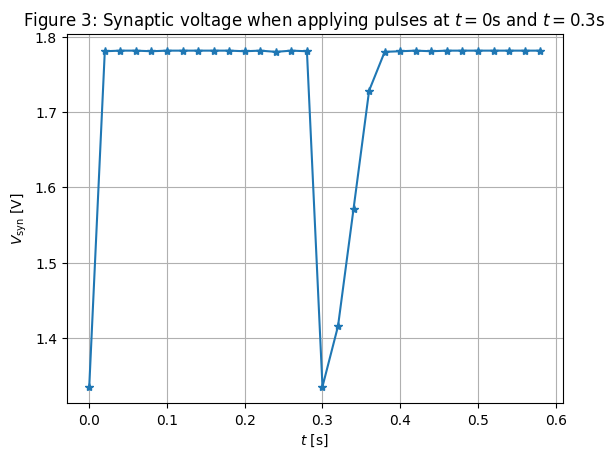

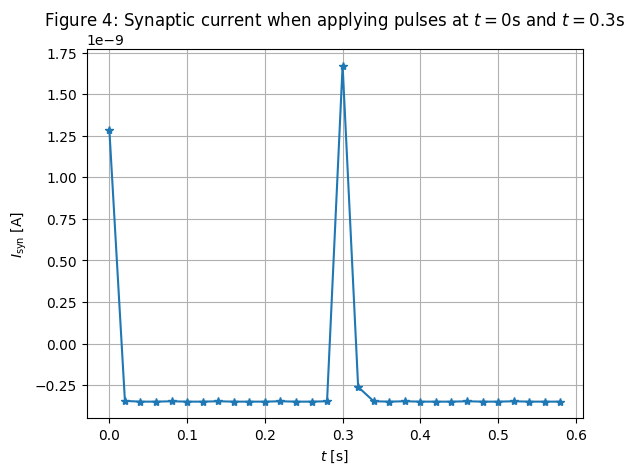

In [10]:
plt.plot(t, vsyn, '-*')
plt.xlabel('$t$ [s]')
plt.ylabel('$V_{\\rm syn}$ [V]')
plt.title('Figure 3: Synaptic voltage when applying pulses at $t = 0$s and $t = 0.3$s')
plt.grid()
plt.show()

plt.plot(t, C2F.f2i(isyn),'-*')
plt.xlabel('$t$ [s]')
plt.ylabel('$I_{\\rm syn}$ [A]')
plt.title('Figure 4: Synaptic current when applying pulses at $t = 0$s and $t = 0.3$s')
plt.grid()
plt.show()

In [11]:
# if the data looks nice, save it!
savevars(datapath/'baseline')

[INFO]: 2025-11-11 15:55:43,481 - saveloadvars - Saved to data/dpi/baseline.dill variables [ datapath N_pulses N_samples_per_pulse N_samples dT t vsyn isyn k i ] (File "/opt/miniconda3/envs/ne1/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 219, in savevars)
[WARNING]: 2025-11-11 15:55:43,485 - saveloadvars - could not pickle: ['c', 'C2F'] (File "/opt/miniconda3/envs/ne1/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 221, in savevars)


In [12]:
# maybe you need to load your saved data?
loadvars(datapath/'baseline')

[INFO]: 2025-11-11 15:55:54,452 - saveloadvars - cancelled  loadvars from possibly unsafe dill (File "/opt/miniconda3/envs/ne1/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 273, in loadvars)


 * <font color=#108ee9> How fine should our measurement be in time to be able to see the exponential behaviour
   of $I_{\rm syn}$? </font>

<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">

ms - $\mu \mathrm{s}$ 

</div>

## 4.2 Different $I_{\rm weight}$

All the following exercise sections are identical to the one just completed. The only difference is we try to 
probe the behaviour of the device with different biasing conditions.

In [13]:
# alias to the bias values set in the previous block
c.set_dpi_baseline()

fine_values = [20, 50, 100]

- **Data acquisition**

In [14]:
N_pulses = 2 # for each trial, send 2 input pulses
N_samples_per_pulse = 15 # for each input pulse, sample 10 points

N_samples = N_pulses*N_samples_per_pulse

dT = 0.02 # delta t between the samples, DO NOT CHANGE

t = np.arange(N_samples)*dT
vsyn = np.zeros([N_samples, len(fine_values)])
isyn = np.zeros([N_samples, len(fine_values)])

for idx, f in tqdm(enumerate(fine_values)):
    c.set_bias(
        pyplane.Coach.BiasAddress.DPI_VWEIGHT_N,
        pyplane.Coach.BiasType.N,
        pyplane.Coach.BiasGenMasterCurrent.I30nA,
        f
    )
    time.sleep(0.1)
    for k in range(N_pulses):
        c.send_dpi_pulse()
        
        for i in range(N_samples_per_pulse):
            vsyn[k*N_samples_per_pulse+i, idx] += c.measure_dpi_vsyn()
            isyn[k*N_samples_per_pulse+i, idx] += c.measure_c2f_freqs(duration=dT)[9]

3it [00:02,  1.12it/s]


* Plot data

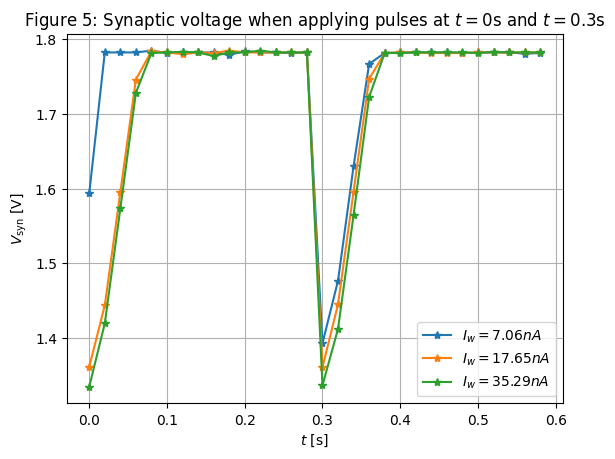

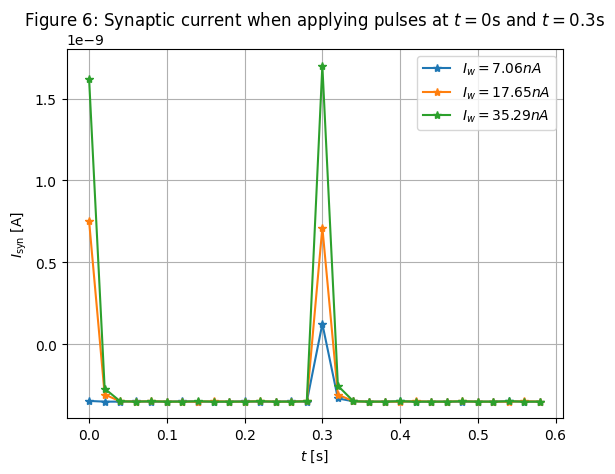

In [15]:
for idx, f in enumerate(fine_values):
    plt.plot(t, vsyn[:,idx], '-*')
plt.xlabel('$t$ [s]')
plt.ylabel('$V_{\\rm syn}$ [V]')
plt.title('Figure 5: Synaptic voltage when applying pulses at $t = 0$s and $t = 0.3$s')
plt.legend([f"$I_{{w}} = {ef(30e-9 * i * 3 / 255)}A$" for i in fine_values])
plt.grid()
plt.show()

for idx, f in enumerate(fine_values):
    plt.plot(t, C2F.f2i(isyn[:,idx]),'-*')
plt.xlabel('$t$ [s]')
plt.ylabel('$I_{\\rm syn}$ [A]')
plt.legend([f"$I_{{w}} = {ef(30e-9 * i * 3 / 255)}A$" for i in fine_values])
plt.title('Figure 6: Synaptic current when applying pulses at $t = 0$s and $t = 0.3$s')
plt.grid()
plt.show()

In [16]:
# if the data looks nice, save it!
savevars(datapath/'iweight')

[INFO]: 2025-11-11 15:58:26,609 - saveloadvars - Saved to data/dpi/iweight.dill variables [ datapath N_pulses N_samples_per_pulse N_samples dT t vsyn isyn k i fine_values idx f ] (File "/opt/miniconda3/envs/ne1/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 219, in savevars)
[WARNING]: 2025-11-11 15:58:26,610 - saveloadvars - could not pickle: ['c', 'C2F'] (File "/opt/miniconda3/envs/ne1/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 221, in savevars)


In [ ]:
# maybe you need to load your saved data?
loadvars(datapath/'iweight')

Figures 5 and 6 confirm the behaviour expected from theory:
the larger $I_w$ (i.e. the weight of the synapse), the larger the current generated at the
output, corresponding to a larger decrease in the voltage driving the gate of the output
transistor. If the C2F characteristic were to be linear, Figure 6 would also confirm the
linear dependency of the current to $I_w$, given that approximately doubling $I_w$ causes a
doubling in the output current.

## 4.3 Different $I_{tau}$

In [17]:
# alias to the bias values set in the previous block
c.set_dpi_baseline()

fine_values = [2, 5, 10]

- **Data acquisition**

In [18]:
N_pulses = 2 # for each trial, send 2 input pulses
N_samples_per_pulse = 15 # for each input pulse, sample 10 points

N_samples = N_pulses*N_samples_per_pulse

dT = 0.02 # delta t between the samples, DO NOT CHANGE

t = np.arange(N_samples)*dT
vsyn = np.zeros([N_samples, len(fine_values)])
isyn = np.zeros([N_samples, len(fine_values)])

for idx, f in tqdm(enumerate(fine_values)):
    c.set_bias(
        pyplane.Coach.BiasAddress.DPI_VTAU_P,
        pyplane.Coach.BiasType.P,
        pyplane.Coach.BiasGenMasterCurrent.I60pA,
        f
    ) 
    time.sleep(0.1)
    for k in range(N_pulses):
        c.send_dpi_pulse()
        
        for i in range(N_samples_per_pulse):
            vsyn[k*N_samples_per_pulse+i, idx] += c.measure_dpi_vsyn()
            isyn[k*N_samples_per_pulse+i, idx] += c.measure_c2f_freqs(duration=dT)[9]

3it [00:02,  1.11it/s]


* Plot data

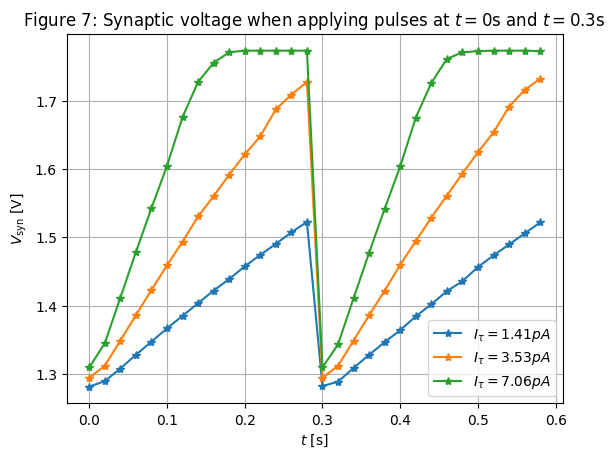

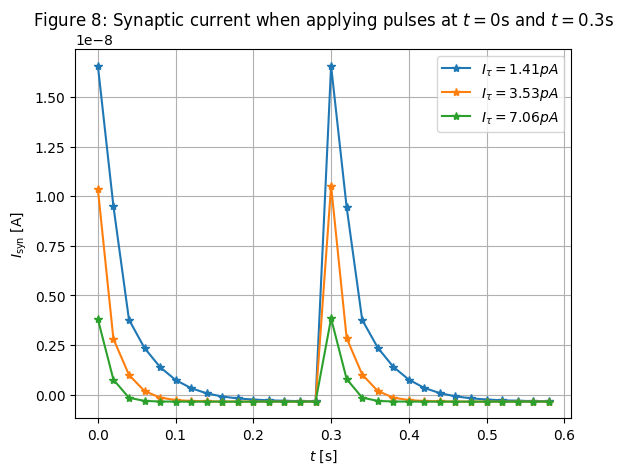

In [19]:
for idx, f in enumerate(fine_values):
    plt.plot(t, vsyn[:,idx], '-*')
plt.xlabel('$t$ [s]')
plt.ylabel('$V_{\\rm syn}$ [V]')
plt.title('Figure 7: Synaptic voltage when applying pulses at $t = 0$s and $t = 0.3$s')
plt.legend([f"$I_{{\\tau}} = {ef(60e-12 * i * 3 / 255)}A$" for i in fine_values])
plt.grid()

plt.show()

for idx, f in enumerate(fine_values):
    plt.plot(t, C2F.f2i(isyn[:,idx]),'-*')
plt.xlabel('$t$ [s]')
plt.ylabel('$I_{\\rm syn}$ [A]')
plt.legend([f"$I_{{\\tau}} = {ef(60e-12 * i * 3 / 255)}A$" for i in fine_values])
plt.title('Figure 8: Synaptic current when applying pulses at $t = 0$s and $t = 0.3$s')
plt.grid()
plt.show()

In [20]:
# if the data looks nice, save it!
savevars(datapath/'itau')

[INFO]: 2025-11-11 16:02:16,337 - saveloadvars - Saved to data/dpi/itau.dill variables [ datapath N_pulses N_samples_per_pulse N_samples dT t vsyn isyn k i fine_values idx f ] (File "/opt/miniconda3/envs/ne1/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 219, in savevars)
[WARNING]: 2025-11-11 16:02:16,339 - saveloadvars - could not pickle: ['c', 'C2F'] (File "/opt/miniconda3/envs/ne1/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 221, in savevars)


In [ ]:
# maybe you need to load your saved data?
loadvars(datapath/'itau')

As you should have shown in the prelab, given the formula
$$\tau = \frac{C \cdot U_T}{\kappa \cdot I_{\tau}}$$
smaller values of $I_{\tau}$ result in larger time costants.

We can see this in Figure 8, where smaller $\tau$ lead to currents that show longer
exponential decay. Additionally, it should be noted that the chosen small $I_\tau$ value is such that $V_{syn}$ is not able to saturate between consecutive spikes.

## 4.4 Different $I_{thr}$

In [21]:
# alias to the bias values set in the previous block
c.set_dpi_baseline()

fine_values = [5, 10, 20]

- **Data acquisition**

In [22]:
N_pulses = 2 # for each trial, send 2 input pulses
N_samples_per_pulse = 15 # for each input pulse, sample 10 points

N_samples = N_pulses*N_samples_per_pulse

dT = 0.02 # delta t between the samples, DO NOT CHANGE

t = np.arange(N_samples)*dT
vsyn = np.zeros([N_samples, len(fine_values)])
isyn = np.zeros([N_samples, len(fine_values)])

for idx, f in tqdm(enumerate(fine_values)):
    c.set_bias(
        pyplane.Coach.BiasAddress.DPI_VTHR_N,
        pyplane.Coach.BiasType.P,
        pyplane.Coach.BiasGenMasterCurrent.I60pA,
        f
    )
    time.sleep(0.1)
    for k in range(N_pulses):
        c.send_dpi_pulse()
        
        for i in range(N_samples_per_pulse):
            vsyn[k*N_samples_per_pulse+i, idx] += c.measure_dpi_vsyn()
            isyn[k*N_samples_per_pulse+i, idx] += c.measure_c2f_freqs(duration=dT)[9]

3it [00:02,  1.13it/s]


* Plot data

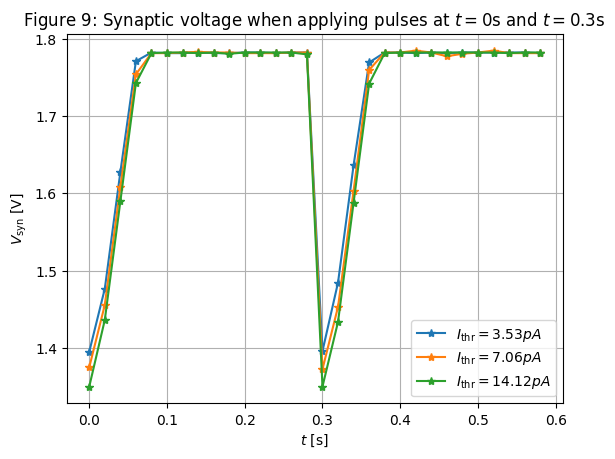

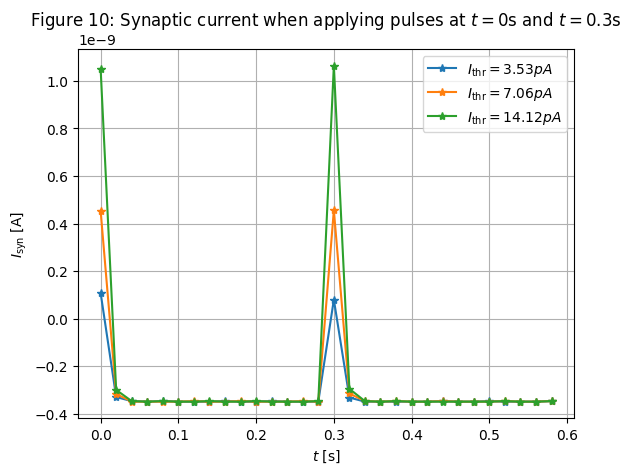

In [23]:
for idx, f in enumerate(fine_values):
    plt.plot(t, vsyn[:,idx], '-*')
plt.xlabel('$t$ [s]')
plt.ylabel('$V_{\\rm syn}$ [V]')
plt.title('Figure 9: Synaptic voltage when applying pulses at $t = 0$s and $t = 0.3$s')
plt.legend([f"$I_{{\\rm thr}} = {ef(60e-12 * i * 3 / 255)}A$" for i in fine_values])
plt.grid()
plt.show()

for idx, f in enumerate(fine_values):
    plt.plot(t, C2F.f2i(isyn[:,idx]),'-*')
plt.xlabel('$t$ [s]')
plt.ylabel('$I_{\\rm syn}$ [A]')
plt.legend([f"$I_{{\\rm thr}} = {ef(60e-12 * i * 3 / 255)}A$" for i in fine_values])
plt.title('Figure 10: Synaptic current when applying pulses at $t = 0$s and $t = 0.3$s')
plt.grid()
plt.show()

In [26]:
# if the data looks nice, save it!
savevars(datapath/'ithr')

[INFO]: 2025-11-11 16:03:33,103 - saveloadvars - Saved to data/dpi/ithr.dill variables [ datapath N_pulses N_samples_per_pulse N_samples dT t vsyn isyn k i fine_values idx f ] (File "/opt/miniconda3/envs/ne1/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 219, in savevars)
[WARNING]: 2025-11-11 16:03:33,113 - saveloadvars - could not pickle: ['c', 'C2F'] (File "/opt/miniconda3/envs/ne1/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 221, in savevars)


In [ ]:
# maybe you need to load your saved data?
loadvars(datapath/'ithr')

## 4.5 Different pulse width

In [27]:
# alias to the bias values set in the previous block
c.set_dpi_baseline()

fine_values = [2, 5, 15]

- **Data acquisition**

In [28]:
N_pulses = 2 # for each trial, send 2 input pulses
N_samples_per_pulse = 15 # for each input pulse, sample 10 points

N_samples = N_pulses*N_samples_per_pulse

dT = 0.02 # delta t between the samples, DO NOT CHANGE

t = np.arange(N_samples)*dT
vsyn = np.zeros([N_samples, len(fine_values)])
isyn = np.zeros([N_samples, len(fine_values)])

for idx, f in tqdm(enumerate(fine_values)):
    c.set_bias(
        pyplane.Coach.BiasAddress.PEX_VTAU_N,
        pyplane.Coach.BiasType.N,
        pyplane.Coach.BiasGenMasterCurrent.I60pA,
        f
    ) 
    time.sleep(0.1)
    for k in range(N_pulses):
        c.send_dpi_pulse()
        
        for i in range(N_samples_per_pulse):
            vsyn[k*N_samples_per_pulse+i, idx] += c.measure_dpi_vsyn()
            isyn[k*N_samples_per_pulse+i, idx] += c.measure_c2f_freqs(duration=dT)[9]

3it [00:02,  1.13it/s]


* Plot data

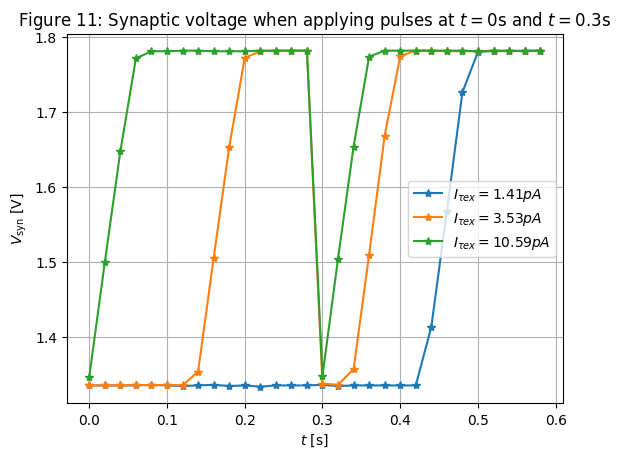

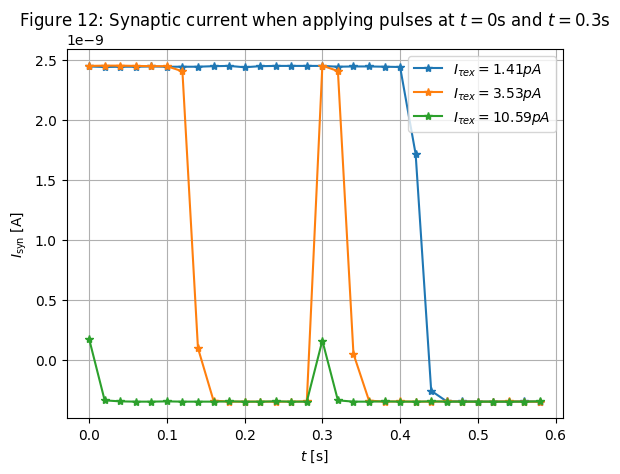

In [29]:
for idx, f in enumerate(fine_values):
    plt.plot(t, vsyn[:,idx], '-*')
plt.xlabel('$t$ [s]')
plt.ylabel('$V_{\\rm syn}$ [V]')
plt.title('Figure 11: Synaptic voltage when applying pulses at $t = 0$s and $t = 0.3$s')
plt.legend([f"$I_{{\\tau ex}} = {ef(60e-12 * i * 3 / 255)}A$" for i in fine_values])
plt.grid()

plt.show()

for idx, f in enumerate(fine_values):
    plt.plot(t, C2F.f2i(isyn[:,idx]),'-*')
plt.xlabel('$t$ [s]')
plt.ylabel('$I_{\\rm syn}$ [A]')
plt.legend([f"$I_{{\\tau ex}} = {ef(60e-12 * i * 3 / 255)}A$" for i in fine_values])
plt.title('Figure 12: Synaptic current when applying pulses at $t = 0$s and $t = 0.3$s')
plt.grid()
plt.show()

In [30]:
# if the data looks nice, save it!
savevars(datapath/'weight')

[INFO]: 2025-11-11 16:04:12,038 - saveloadvars - Saved to data/dpi/weight.dill variables [ datapath N_pulses N_samples_per_pulse N_samples dT t vsyn isyn k i fine_values idx f ] (File "/opt/miniconda3/envs/ne1/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 219, in savevars)
[WARNING]: 2025-11-11 16:04:12,039 - saveloadvars - could not pickle: ['c', 'C2F'] (File "/opt/miniconda3/envs/ne1/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 221, in savevars)


In [ ]:
# maybe you need to load your saved data?
loadvars(datapath/'weight')

[INFO]: 2025-11-11 16:04:16,838 - saveloadvars - cancelled  loadvars from possibly unsafe dill (File "/opt/miniconda3/envs/ne1/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 273, in loadvars)


: 

Figure 11 shows well the different pulse widths reflected on $V_{syn}$:
the longer the pulse width, the larger the decrease in $V_{syn}$
(and, in case the lower bound is reached, the longer its duration).

Figure 12 shows the current $I_{syn}$ response to different pulse widths and, as we expect,
whenever $V_{syn}$ reaches the lower bound, the output current maintains a steady output too,
until the gate voltage of the output transistor starts increasing again, at the end of the
input pulse.

## 5 Postlab - What we expect you to learn

There is no specific postlab for this exercise.

Please see the [NE1 exam preparation guide](https://drive.google.com/file/d/1nOq3UbcEv_ik425VBYqcH9hAET7FyIeP/view?usp=drive_link)
